# Model Fitting and Evaluation

The main goal of this notebook is to fit the proposed models to the available data and evaluate its performance and validity.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "processed-s1.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models.tumor_model_basic import simulate_tumor_basic
from src.models.tumor_model_advanced import simulate_tumor_advanced

from src.models.fit_model_basic import fit_model_basic, loss_function
from src.models.fit_model_advanced import fit_model_advanced

In [2]:
# 1. Load data
data = pd.read_csv(DATA_PATH)

# 2. Extract relevant columns
T_obs = data["LOGVOL"].to_numpy()
times = data["DAYS"].to_numpy()
D_values = data["DOSE"].to_numpy()

## Basic Model

Firstly the basic mechanistic model will be fitted (it does not contemplate acquired resistance to treatment). This model will serve as a benchmark for the advanced one (which does contemplate acquired resistance), and it will be assessed whether the addition of the extra parameters improves significantly the performance of the model.

In [3]:
seed = 23 ; maxiter = 10000 ; popsize = 15

results_df = fit_model_basic(T_obs,
                             D_values,
                             times,
                             seed,
                             maxiter,
                             popsize)

%time

CPU times: total: 0 ns
Wall time: 0 ns


In [6]:
# Simulate tumor volume evolution for all treatments
T0 = data["LOGVOL"].iloc[0]

r_0 = results_df["r"].iloc[0]
K_0 = results_df["K"].iloc[0]
al_0 = results_df["al"].iloc[0]
times_0 = times[:11]
simulation_0 = simulate_tumor_basic(T0=T0,
                                    r=r_0,
                                    K=K_0,
                                    al=al_0,
                                    times=times_0,
                                    D_values=D_values)

results_df.head(10)

,ID,r,K,al,MSE
0,0,0.961836,10.218417,0.000000,1000000.0
1,1,0.961836,10.218417,0.029009,1000000.0
2,2,0.961836,10.218417,0.005488,1000000.0
3,3,0.961836,10.218417,0.015035,1000000.0
4,4,0.961836,10.218417,0.017066,1000000.0


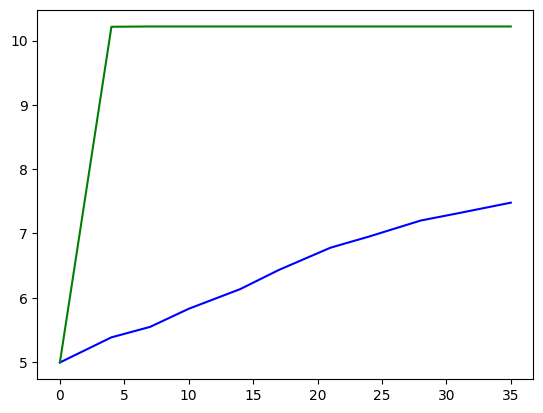

In [5]:
df_mouse0 = data.iloc[:11]
plt.plot(df_mouse0["DAYS"], df_mouse0["LOGVOL"], color="blue")

plt.plot(simulation_0["DAYS"], simulation_0["VOL"], color="green")